# EE-411 Lottery Ticket Hypothesis - Figures: Resnet-18 + Iterative + Random Init

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.16]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [1]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_create_figures_3_trials"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_create_figures_3_trials_20260123_201032
Results will be saved to: ../../results/resnet20_create_figures_3_trials_20260123_201032


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Generate Figures

Plotting 10k...


/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_22683/2518066266.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location='

Plotting 20k...


/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_22683/2518066266.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location='

Plotting 30k...


/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_22683/2518066266.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location='

Saved corrected plot to ../../results/resnet20_create_figures_3_trials_20260123_201032/figures/reproduced_figure_8_3trials_errorbars_corrected_resnet20_create_figures_3_trials_20260123_201032.png


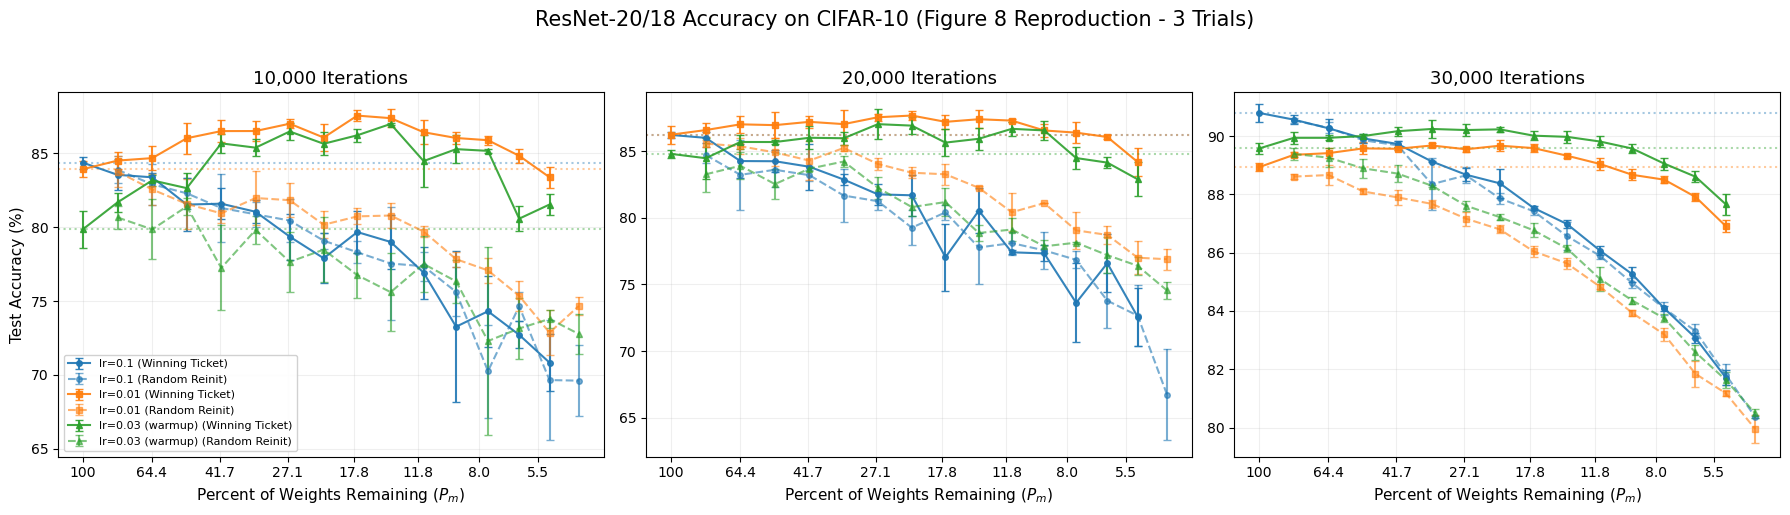

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 0. Define File Paths (Updated for 3-Trial Data)
# ==========================================

# 1. LR = 0.1 (Standard, Blue)
path_iter_01 = "../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.pth"
path_rand_01 = "../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.pth"

# 2. LR = 0.01 (Low LR, Orange)
path_iter_001 = "../../results/resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930.pth"
path_rand_001 = "../../results/resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930.pth"

# 3. LR = 0.03 + Warmup (Proposed, Green)
path_iter_warmup = "../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924.pth"
path_rand_warmup = "../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924.pth"

# Define Epoch mapping indices
# 10k iters ~ epoch 29 (idx 28), 20k iters ~ epoch 57 (idx 56), 30k iters = Final
EPOCH_INDICES = {
    '10k': 28, 
    '20k': 56, 
    '30k': -1 # Last epoch
}

# ==========================================
# 1. Data Extraction Helper Functions
# ==========================================

def extract_history_acc(history, epoch_idx):
    """Helper to safely extract accuracy from history dict/list at specific index."""
    if history is None: return None
    acc_list = None
    possible_keys = ['test_accuracy', 'test_acc', 'val_accuracy', 'val_acc', 'accuracy', 'acc']
    
    if isinstance(history, dict):
        for k in possible_keys:
            if k in history:
                acc_list = history[k]; break
    elif isinstance(history, list):
        acc_list = history
        
    if acc_list is None or len(acc_list) == 0: return None
    
    # Handle negative index or out of bounds
    if epoch_idx == -1: return acc_list[-1]
    if epoch_idx >= len(acc_list): return acc_list[-1]
    
    return acc_list[epoch_idx]

def load_aggregated_data(path, step_name, is_iterative=False):
    """
    Loads 3-trial data, calculates Mean and Std for each pruning round.
    Handles the shift for iterative pruning curves (aligning acc with correct sparsity).
    
    Args:
        path (str): Path to .pth file
        step_name (str): '10k', '20k', or '30k'
        is_iterative (bool): If True, shifts X-axis to align [100%, 80%, ...] with accuracies.
        
    Returns: 
        x (sparsity array), y_mean (accuracy array), y_std (error array)
    """
    if not os.path.exists(path):
        print(f"Warning: File not found: {path}")
        return [], [], []
    
    try:
        checkpoint = torch.load(path, map_location='cpu')
        
        # Robustly extract the trials list
        if isinstance(checkpoint, dict):
            if 'trials' in checkpoint:
                trials_data = checkpoint['trials'] # List[List[Dict]]
            elif 'results' in checkpoint:
                trials_data = [checkpoint['results']] # Fallback for single trial format
            else:
                trials_data = checkpoint if isinstance(checkpoint, list) else []
        else:
            trials_data = checkpoint

        if not trials_data:
            return [], [], []

        n_rounds = len(trials_data[0])
        
        # Prepare lists to hold raw data across rounds
        x_raw_list = [] # Will hold sparsity values (e.g., [80, 64, 51...])
        y_means = []
        y_stds = []

        target_idx = EPOCH_INDICES[step_name]

        # Iterate through each round
        for r_idx in range(n_rounds):
            
            # 1. Get X-axis (Sparsity) - assume same for all trials (from Trial 0)
            # This 'pct' is the sparsity AFTER pruning in this round.
            pct = trials_data[0][r_idx].get('remaining_params_pct', None)
            if pct is None: continue
            
            x_raw_list.append(pct)
            
            # 2. Get Y-axis (Accuracy) from ALL trials for this round
            accuracies = []
            for trial in trials_data:
                res = trial[r_idx]
                
                if step_name == '30k':
                    acc = res.get('test_accuracy', None)
                else:
                    acc = extract_history_acc(res.get('history'), target_idx)
                
                if acc is not None:
                    accuracies.append(acc)
            
            # 3. Calculate Stats
            if len(accuracies) > 0:
                y_means.append(np.mean(accuracies))
                y_stds.append(np.std(accuracies))
                
        # Convert to numpy arrays
        x_arr = np.array(x_raw_list)
        y_mean_arr = np.array(y_means)
        y_std_arr = np.array(y_stds)
        
        # === SHIFT LOGIC (CRITICAL FIX) ===
        if is_iterative:
            # For Iterative Pruning:
            # Round 0 result contains: Acc of 100% model, Pct of 80% model.
            # We want to plot Acc[0] at 100%.
            # We want to plot Acc[1] at X[0] (80%).
            # So we prepend 100.0 to X array and discard the last X value.
            
            if len(x_arr) > 0:
                # Concatenate 100% to the start
                x_final = np.concatenate(([100.0], x_arr[:-1]))
                return x_final, y_mean_arr, y_std_arr
            else:
                return [], [], []
        else:
            # For Random Reinit:
            # Round 0 result is trained on Mask 0 (80%). Acc is for 80%.
            # So X and Y are already aligned.
            return x_arr, y_mean_arr, y_std_arr

    except Exception as e:
        print(f"Error loading {path}: {e}")
        return [], [], []

# ==========================================
# 2. Plotting Logic (With Error Bars)
# ==========================================
steps = ['10k', '20k', '30k']
titles = ['10,000 Iterations', '20,000 Iterations', '30,000 Iterations']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define Colors
colors = {
    '0.1': 'tab:blue', 
    '0.01': 'tab:orange', 
    'warmup': 'tab:green'
}

for i, step in enumerate(steps):
    ax = axes[i]
    print(f"Plotting {step}...")
    
    # --- Load Data (Apply shift only to iterative) ---
    
    # LR 0.1
    x_i_01, y_i_01, e_i_01 = load_aggregated_data(path_iter_01, step, is_iterative=True)
    x_r_01, y_r_01, e_r_01 = load_aggregated_data(path_rand_01, step, is_iterative=False)
    
    # LR 0.01
    x_i_001, y_i_001, e_i_001 = load_aggregated_data(path_iter_001, step, is_iterative=True)
    x_r_001, y_r_001, e_r_001 = load_aggregated_data(path_rand_001, step, is_iterative=False)
    
    # LR 0.03 Warmup
    x_i_warm, y_i_warm, e_i_warm = load_aggregated_data(path_iter_warmup, step, is_iterative=True)
    x_r_warm, y_r_warm, e_r_warm = load_aggregated_data(path_rand_warmup, step, is_iterative=False)
    
    # --- Plotting ---
    
    # 1. LR = 0.1
    if len(x_i_01) > 0:
        ax.errorbar(x_i_01, y_i_01, yerr=e_i_01, label='lr=0.1 (Winning Ticket)', 
                    color=colors['0.1'], fmt='o-', markersize=4, capsize=3, alpha=0.9)
        # Baseline: Unpruned (First point after shift)
        ax.axhline(y=y_i_01[0], color=colors['0.1'], linestyle=':', alpha=0.4)
        
    if len(x_r_01) > 0:
        ax.errorbar(x_r_01, y_r_01, yerr=e_r_01, label='lr=0.1 (Random Reinit)', 
                    color=colors['0.1'], fmt='o--', markersize=4, capsize=3, alpha=0.6)

    # 2. LR = 0.01
    if len(x_i_001) > 0:
        ax.errorbar(x_i_001, y_i_001, yerr=e_i_001, label='lr=0.01 (Winning Ticket)', 
                    color=colors['0.01'], fmt='s-', markersize=4, capsize=3, alpha=0.9)
        ax.axhline(y=y_i_001[0], color=colors['0.01'], linestyle=':', alpha=0.4)
        
    if len(x_r_001) > 0:
        ax.errorbar(x_r_001, y_r_001, yerr=e_r_001, label='lr=0.01 (Random Reinit)', 
                    color=colors['0.01'], fmt='s--', markersize=4, capsize=3, alpha=0.6)

    # 3. LR = 0.03 Warmup
    if len(x_i_warm) > 0:
        ax.errorbar(x_i_warm, y_i_warm, yerr=e_i_warm, label='lr=0.03 (warmup) (Winning Ticket)', 
                    color=colors['warmup'], fmt='^-', markersize=4, capsize=3, alpha=0.9)
        ax.axhline(y=y_i_warm[0], color=colors['warmup'], linestyle=':', alpha=0.4)
        
    if len(x_r_warm) > 0:
        ax.errorbar(x_r_warm, y_r_warm, yerr=e_r_warm, label='lr=0.03 (warmup) (Random Reinit)', 
                    color=colors['warmup'], fmt='^--', markersize=4, capsize=3, alpha=0.6)

    # --- Formatting ---
    ax.set_xscale('log')
    ax.invert_xaxis()
    
    # Custom Ticks as requested
    custom_ticks = [100, 64.4, 41.7, 27.1, 17.8, 11.8, 8.0, 5.5]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([str(t) for t in custom_ticks])
    ax.minorticks_off()
    
    ax.set_xlabel('Percent of Weights Remaining ($P_m$)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        
    ax.set_title(titles[i], fontsize=13)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # Adjust Y-limit for the final plot
    if i == 2:
        ax.set_ylim(bottom=79.0, top=91.5)

# Legend on first plot
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)

plt.suptitle('ResNet-20/18 Accuracy on CIFAR-10 (Figure 8 Reproduction - 3 Trials)', fontsize=15, y=1.02)
plt.tight_layout()

# Save
save_name = "reproduced_figure_8_3trials_errorbars.png"
if 'fig_dir' in globals() and 'run_id' in globals():
    save_path = os.path.join(fig_dir, f"reproduced_figure_8_3trials_errorbars_corrected_{run_id}.png")
else:
    save_path = save_name

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved corrected plot to {save_path}")
plt.show()